# Import the library

In [636]:
from nsepython import *
import pandas as pd
import numpy as np
import datetime as dt
from typing import List , Dict
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

# Create the classes

In [637]:
class StockPrice:
    def __init__(self , date : str , closing_price : str , ticker : str):
        self.date = dt.datetime.strptime(date , '%d %b %Y')
        self.closing_price = float(closing_price)
        self.ticker = ticker
    
    def __str__(self):
        return f"Date: {self.date} Closing Price: {self.closing_price} ticker: {self.ticker}"
    
    def __repr__(self):
        return self.__str__()
    
    def __lt__(self, other: StockPrice):
        return self.date < other.date

In [638]:
class Ratio:
    def __init__(self , date : dt.datetime , ratio : float):
        self.date = date
        self.ratio = ratio

    def __str__(self):
        return f"Date: {self.date} Ratio: {self.ratio}"
    
    def __repr__(self):
        return self.__str__()
    
    def __lt__(self, other: StockPrice):
        return self.date < other.date

# Function to get index data

In [639]:
def get_index_data(symbol : str , start_date :str , end_date : str) -> List[StockPrice]:
    index_data : pd.DataFrame = index_history(symbol,start_date,end_date)

    index_object_data : List[StockPrice] = []

    for row in index_data.iterrows():
        date = row[1].HistoricalDate
        closing_price = row[1].CLOSE
        ticker = row[1].INDEX_NAME
        
        index_object_data.append(StockPrice(date=date , closing_price=closing_price , ticker=ticker))

    return index_object_data

# Function for calculating jdk rs ratio

In [640]:
def calculate_jdk_rs_ratio_aligned(
    stock_prices: List[StockPrice],
    benchmark_prices: List[StockPrice],
    window: int = 14
) -> List[Ratio]:
    """
    Calculates the JdK RS-Ratio assuming stock and benchmark lists
    are perfectly aligned day-by-day and sorted chronologically.

    Methodology:
    1. Compute the log relative strength (log RS) of stock vs benchmark.
    2. Normalize log RS using a rolling Z-score over `window` periods.
    3. Scale and center at 100 to produce the RS-Ratio.
    4. Apply exponential smoothing (EMA) to reduce noise.
    """

    # 1. Extract closing prices into pandas Series
    stock_series = pd.Series([sp.closing_price for sp in stock_prices], dtype=float)
    benchmark_series = pd.Series([bp.closing_price for bp in benchmark_prices], dtype=float)

    # 2. Calculate log Relative Strength
    #    Log RS is preferred because it treats equal up/down moves symmetrically
    #    and prevents ratio distortion from compounding.
    log_rs = np.log(stock_series / benchmark_series)

    # 3. Normalize using a rolling Z-score over the lookback window
    rolling_mean = log_rs.rolling(window=window).mean()
    rolling_std = log_rs.rolling(window=window).std(ddof=1)

    z_score = (log_rs - rolling_mean) / rolling_std

    # 4. Scale and center at 100
    #    The scaling factor (e.g. 10) controls sensitivity.
    #    Values > 100 indicate outperformance, < 100 underperformance.
    rs_ratio = 100 + (z_score * 10)

    # 5. Apply Exponential Moving Average smoothing
    #    EMA is standard for RRGs — it weights recent data more heavily
    #    than a simple rolling mean, reducing lag while still smoothing noise.
    rs_ratio_smoothed = rs_ratio.ewm(span=window, adjust=False).mean()

    # 6. Map results back to original dates, dropping NaN periods
    final_ratios = [
        Ratio(stock_prices[i].date, round(rs_ratio_smoothed.iloc[i], 4))
        for i in range(len(stock_prices))
        if not pd.isna(rs_ratio_smoothed.iloc[i])
    ]

    return final_ratios

In [641]:
def calculate_jdk_rs_momentum_aligned(
    stock_prices: List[StockPrice],
    benchmark_prices: List[StockPrice],
    window: int = 14,
    momentum_window: int = 10
) -> List[Ratio]:
    """
    Calculates the JdK RS-Momentum assuming stock and benchmark lists
    are perfectly aligned day-by-day and sorted chronologically.

    Methodology:
    1. Compute the RS-Ratio (same pipeline as calculate_jdk_rs_ratio_aligned).
    2. Compute the Rate of Change (ROC) of the RS-Ratio over `momentum_window` periods.
    3. Normalize the ROC using a rolling Z-score over `window` periods.
    4. Scale and center at 100.
    5. Apply EMA smoothing.
    """

    # 1. Extract closing prices
    stock_series = pd.Series([sp.closing_price for sp in stock_prices], dtype=float)
    benchmark_series = pd.Series([bp.closing_price for bp in benchmark_prices], dtype=float)

    # 2. Compute log RS and derive the RS-Ratio (mirrors the ratio function exactly)
    log_rs = np.log(stock_series / benchmark_series)

    rolling_mean = log_rs.rolling(window=window).mean()
    rolling_std = log_rs.rolling(window=window).std(ddof=1)

    rs_ratio = 100 + ((log_rs - rolling_mean) / rolling_std) * 10
    rs_ratio_smoothed = rs_ratio.ewm(span=window, adjust=False).mean()

    # 3. Rate of Change of the RS-Ratio
    #    Momentum measures how fast the RS-Ratio itself is changing —
    #    so ROC must be applied to the smoothed RS-Ratio, not raw RS.
    #    Using log ROC keeps the same symmetry benefits as log RS.
    log_roc = np.log(rs_ratio_smoothed / rs_ratio_smoothed.shift(momentum_window))

    # 4. Normalize the ROC using a rolling Z-score
    roc_rolling_mean = log_roc.rolling(window=window).mean()
    roc_rolling_std = log_roc.rolling(window=window).std(ddof=1)

    z_score = (log_roc - roc_rolling_mean) / roc_rolling_std

    # 5. Scale and center at 100 (same convention as RS-Ratio)
    rs_momentum = 100 + (z_score * 10)

    # 6. Apply EMA smoothing
    rs_momentum_smoothed = rs_momentum.ewm(span=window, adjust=False).mean()

    # 7. Map results back to original dates, dropping NaN periods
    final_momentum: List[Ratio] = [
        Ratio(date=stock_prices[i].date, ratio=round(rs_momentum_smoothed.iloc[i], 4))
        for i in range(len(stock_prices))
        if not pd.isna(rs_momentum_smoothed.iloc[i])
    ]

    return final_momentum

# Test

In [642]:
def create_rs_ratio_momentum(stock_prices: List[StockPrice], benchmark_prices: List[StockPrice]) -> Dict[str, List[Ratio]]:
    rs_ratio = calculate_jdk_rs_ratio_aligned(stock_prices, benchmark_prices)
    rs_momentum = calculate_jdk_rs_momentum_aligned(stock_prices, benchmark_prices)

    return {
        "rs_ratios": rs_ratio,
        "rs_momentums": rs_momentum
    }

In [643]:
def plot_rrg_from_ratios(
    ticker_data: dict[str, dict[str, List[Ratio]]],
):
    fig, ax = plt.subplots(figsize=(14, 12))
    colors = plt.cm.tab10.colors
    legend_handles = []

    for idx, (ticker_name, data) in enumerate(ticker_data.items()):
        rs_ratios_list    = data["rs_ratios"]
        rs_momentums_list = data["rs_momentums"]
        color             = colors[idx % len(colors)]

        # 1. Align ratio and momentum on date
        df_ratio    = pd.DataFrame([{'Date': r.date, 'RS_Ratio': r.ratio} for r in rs_ratios_list])
        df_momentum = pd.DataFrame([{'Date': m.date, 'RS_Momentum': m.ratio} for m in rs_momentums_list])
        df          = pd.merge(df_ratio, df_momentum, on='Date', how='inner')
        df          = df.sort_values(by='Date').reset_index(drop=True)

        if df.empty:
            print(f"Warning: No overlapping dates for {ticker_name}, skipping.")
            continue

        # 2. Draw the historical trail
        ax.plot(
            df['RS_Ratio'], df['RS_Momentum'],
            linestyle='-', color=color, alpha=0.4, linewidth=1.5
        )

        # 3. Draw intermediate points as small filled markers, numbered chronologically
        for i in range(len(df) - 1):
            ax.plot(
                df['RS_Ratio'].iloc[i], df['RS_Momentum'].iloc[i],
                marker='o', linestyle='None',
                color=color, alpha=0.4, markersize=4
            )
            ax.annotate(
                str(i + 1),
                xy=(df['RS_Ratio'].iloc[i], df['RS_Momentum'].iloc[i]),
                xytext=(4, 4), textcoords='offset points',
                fontsize=6, color=color, alpha=0.6
            )

        # 4. Highlight the most recent point with ticker label
        current_ratio    = df['RS_Ratio'].iloc[-1]
        current_momentum = df['RS_Momentum'].iloc[-1]
        current_date     = df['Date'].iloc[-1]
        first_date       = df['Date'].iloc[0]

        ax.plot(
            current_ratio, current_momentum,
            marker='*', linestyle='None',
            color=color, markersize=14
        )
        ax.annotate(
            ticker_name,
            xy=(current_ratio, current_momentum),
            xytext=(6, 6), textcoords='offset points',
            fontsize=9, fontweight='bold', color=color
        )

        # 5. Build a rich legend entry per ticker
        handle = mlines.Line2D(
            [], [],
            color=color,
            marker='*',
            markersize=10,
            linewidth=1.5,
            label=f"{ticker_name}  |  {first_date.strftime('%d %b %y')} → {current_date.strftime('%d %b %y')}  |  Ratio: {current_ratio:.2f}  Momentum: {current_momentum:.2f}"
        )
        legend_handles.append(handle)

    # --- Quadrant lines centered at 100 ---
    ax.axvline(x=100, color='black', linestyle='-', linewidth=1.5)
    ax.axhline(y=100, color='black', linestyle='-', linewidth=1.5)

    # --- Quadrant background shading ---
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    ax.axvspan(100, x_max, ymin=0.5, ymax=1.0, alpha=0.04, color='green')
    ax.axvspan(x_min, 100, ymin=0.5, ymax=1.0, alpha=0.04, color='blue')
    ax.axvspan(x_min, 100, ymin=0.0, ymax=0.5, alpha=0.04, color='red')
    ax.axvspan(100, x_max, ymin=0.0, ymax=0.5, alpha=0.04, color='orange')

    # --- Quadrant labels ---
    ax.text(100.3, y_max - 0.2, 'LEADING\nOutperforming & Strengthening',
            color='green', fontsize=9, alpha=0.9, verticalalignment='top' , horizontalalignment='left')
    ax.text(99.7, y_max - 0.2, 'IMPROVING\nUnderperforming & Strengthening',
            color='blue', fontsize=9, alpha=0.9, verticalalignment='top', horizontalalignment='right')
    ax.text(99.7, y_min + 0.2, 'LAGGING\nUnderperforming & Weakening',
            color='red', fontsize=9, alpha=0.9, verticalalignment='bottom', horizontalalignment='right')
    ax.text(100.3, y_min + 0.2, 'WEAKENING\nOutperforming & Weakening',
            color='orange', fontsize=9, alpha=0.9, verticalalignment='bottom' , horizontalalignment='left')

    # --- Legend ---
    # Quadrant legend entries
    quadrant_handles = [
        mpatches.Patch(color='green',  alpha=0.3, label='Leading   — Ratio > 100, Momentum > 100'),
        mpatches.Patch(color='blue',   alpha=0.3, label='Improving — Ratio < 100, Momentum > 100'),
        mpatches.Patch(color='red',    alpha=0.3, label='Lagging   — Ratio < 100, Momentum < 100'),
        mpatches.Patch(color='orange', alpha=0.3, label='Weakening — Ratio > 100, Momentum < 100'),
    ]

    # Ticker legend entries sit above quadrant entries
    ax.legend(
        handles=legend_handles + [plt.Line2D([], [], linestyle='none')] + quadrant_handles,
        loc='upper left',
        fontsize=8,
        framealpha=0.8,
        title='── Tickers ──────────────────────────────────\n\n── Quadrants ─────────────────────────────',
        title_fontsize=7
    )

    # --- Trail numbering note ---
    ax.text(
        0.01, 0.01,
        '① ② ... = chronological order of data points along each trail',
        transform=ax.transAxes,
        fontsize=7, color='gray', verticalalignment='bottom'
    )

    # --- Chart formatting ---
    ax.set_title('Relative Rotation Graph (RRG)', fontsize=14, fontweight='bold')
    ax.set_xlabel('JdK RS-Ratio', fontsize=12)
    ax.set_ylabel('JdK RS-Momentum', fontsize=12)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('rrg_multi_ticker.png', dpi=150)
    plt.show()

In [644]:
start_date = "01-Jan-2026"
end_date   = "12-May-2026"

tickers = ["NIFTY IT" , "NIFTY PHARMA" , "NIFTY FMCG" , "NIFTY BANK" , "NIFTY AUTO" , "NIFTY METAL"]
benchmark = sorted(get_index_data(symbol = "NIFTY 50" ,start_date = start_date , end_date = end_date))

ticker_data = {}
for ticker in tickers:
    ticker_prices = sorted(get_index_data(symbol = ticker ,start_date = start_date , end_date = end_date))
    ticker_data[ticker] = create_rs_ratio_momentum(ticker_prices, benchmark)

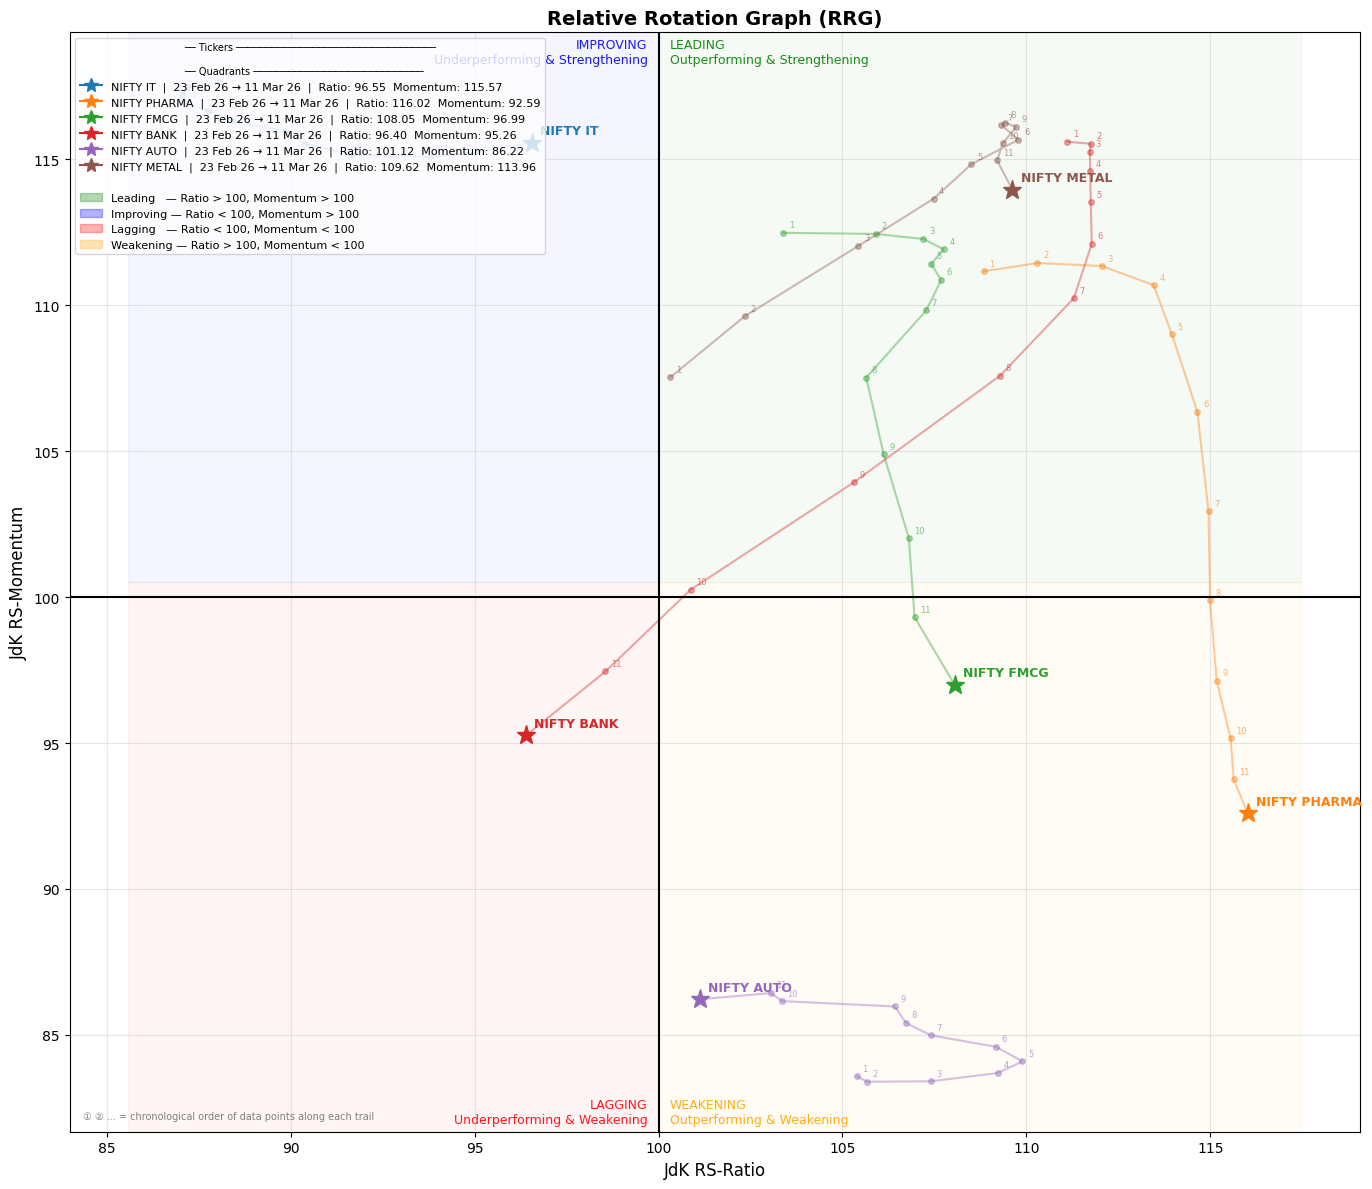

In [645]:
plot_rrg_from_ratios(ticker_data)